In [1]:
import numpy as np
import plotly.graph_objects as go

def get_so4_rotation(psi):
    """
    Generates an SO(4) rotation matrix for the X-W plane.
    psi: The 'tuning' angle into the W-dimension.
    """
    return np.array([
        [np.cos(psi),  0, 0, np.sin(psi)],
        [0,            1, 0, 0],
        [0,            0, 1, 0],
        [-np.sin(psi), 0, 0, np.cos(psi)]
    ])

def generate_toroidal_coordinates(R=3, r=1, resolution=40):
    theta = np.linspace(0, 2*np.pi, resolution)
    phi = np.linspace(0, 2*np.pi, resolution)
    theta, phi = np.meshgrid(theta, phi)
    
    # 4D coordinates (x, y, z, w) - Initializing w at 0
    x = (R + r*np.cos(phi)) * np.cos(theta)
    y = (R + r*np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    w = np.zeros_like(x)
    
    return x, y, z, w

# Parameters
R, r = 3, 1
psi_val = np.pi / 4  # The tuning angle into the W-axis
x, y, z, w = generate_toroidal_coordinates(R, r)

# Flatten for matrix multiplication
coords_4d = np.stack([x.flatten(), y.flatten(), z.flatten(), w.flatten()])
rotation_matrix = get_so4_rotation(psi_val)
transformed_coords = rotation_matrix @ coords_4d

# Reshape back for plotting
x_rot = transformed_coords[0].reshape(x.shape)
y_rot = transformed_coords[1].reshape(y.shape)
z_rot = transformed_coords[2].reshape(z.shape)
w_rot = transformed_coords[3].reshape(w.shape) # The 'bleeding' into 4D

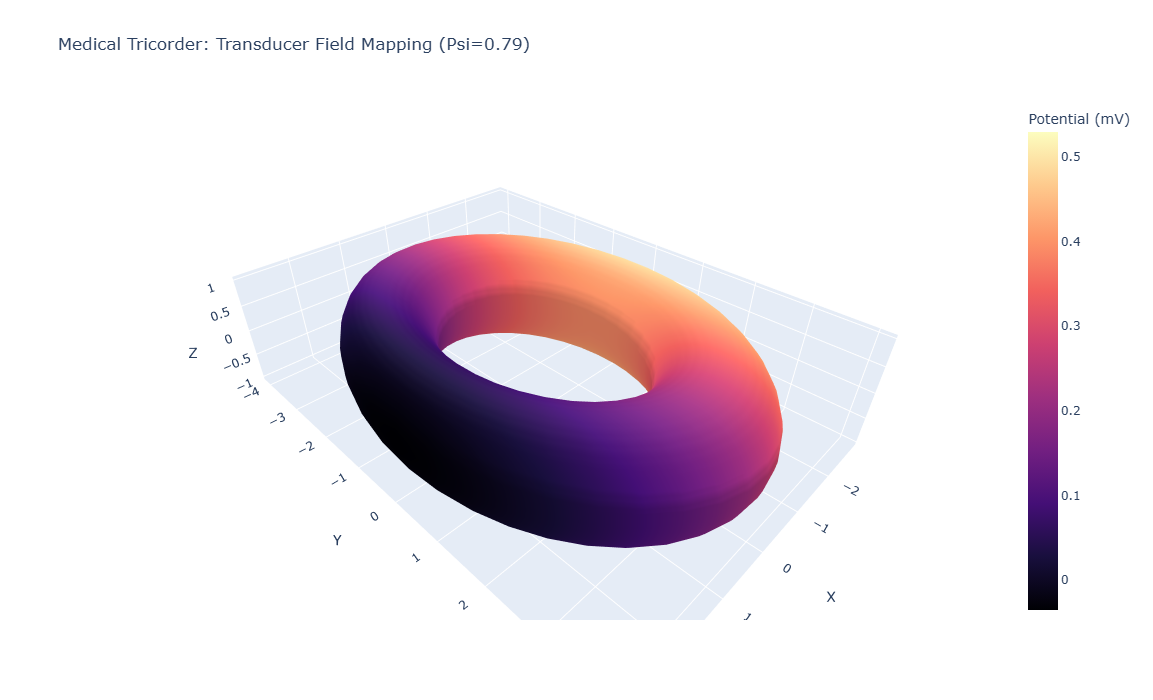

In [2]:
# Define a mock Piezoelectric Tensor (Simplified)
# Representing the conversion of mechanical stress to electrical potential
stress_vector = np.array([1, 0, 0.5]) # Normal/Shear stress on the fascia
d_tensor = np.array([0.2, 0.1, 0.3]) # Piezoelectric coefficients

# Calculate potential based on W-axis depth
# As psi increases (tuning), entropy decreases and potential stabilizes
potential = (np.dot(stress_vector, d_tensor) * np.cos(psi_val)) + (w_rot * 0.1)

# Visualization of the 'Apparatus'
fig = go.Figure(data=[go.Surface(
    x=x_rot, y=y_rot, z=z_rot,
    surfacecolor=potential, 
    colorscale='Magma',
    colorbar_title="Potential (mV)",
    hovertemplate="X: %{x}<br>Y: %{y}<br>Z: %{z}<br>W-Depth: %{surfacecolor}<extra></extra>"
)])

fig.update_layout(
    title=f"Medical Tricorder: Transducer Field Mapping (Psi={psi_val:.2f})",
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
    width=900, height=700
)
fig.show()

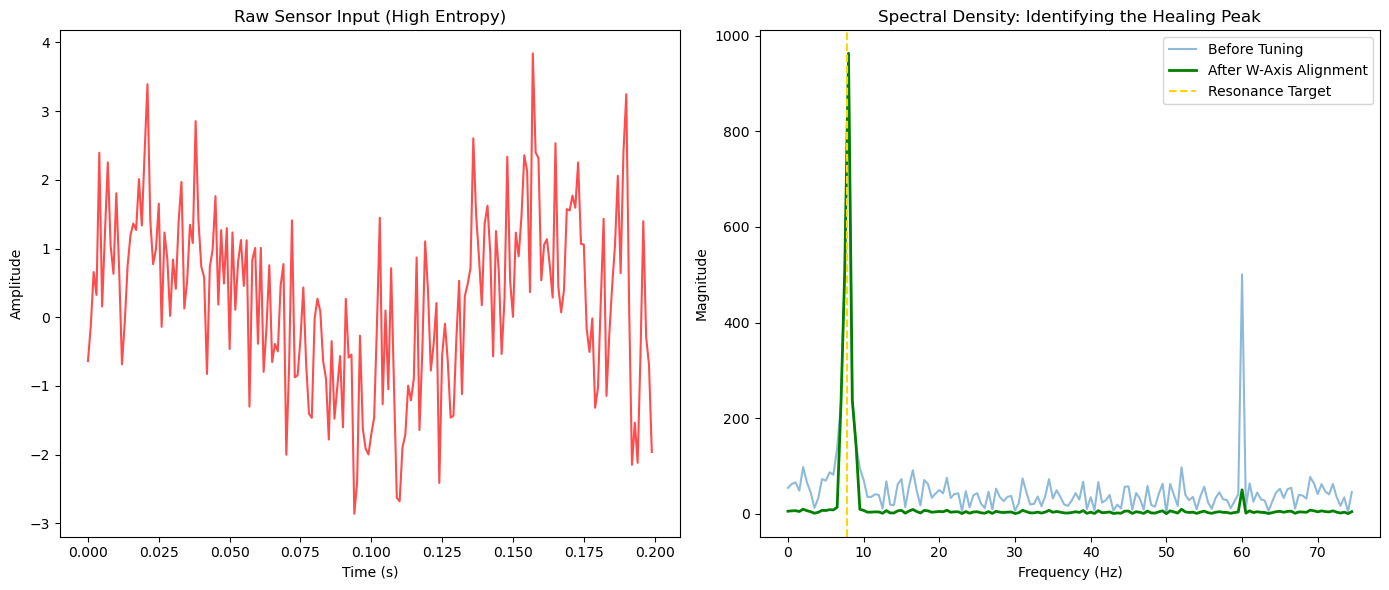

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Bio-Signal parameters
sampling_rate = 1000  # Hz
duration = 2.0        # Seconds
t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# 2. Simulate the 'Incoherent' Signal (Pre-Tuning)
# 7.83 Hz (Schumann) + 60 Hz (Power Line Interference) + Gaussian Noise
target_freq = 7.83 
interference = 60.0
raw_signal = (1.2 * np.sin(2 * np.pi * target_freq * t) + 
              0.5 * np.sin(2 * np.pi * interference * t) + 
              0.8 * np.random.normal(size=t.shape))

# 3. Perform FFT to analyze the current 'Apparatus' state
fft_values = np.fft.rfft(raw_signal)
frequencies = np.fft.rfftfreq(len(t), 1/sampling_rate)
magnitude = np.abs(fft_values)

# 4. Simulation of the 'Tricorder' Filter (Applying W-Axis Coherence)
# This acts as a band-pass filter at the resonance frequency
filtered_magnitude = magnitude.copy()
filtered_magnitude[(frequencies < 7.0) | (frequencies > 9.0)] *= 0.1

# 5. Visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t[:200], raw_signal[:200], color='red', alpha=0.7)
plt.title("Raw Sensor Input (High Entropy)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.plot(frequencies[:150], magnitude[:150], label='Before Tuning', alpha=0.5)
plt.plot(frequencies[:150], filtered_magnitude[:150], label='After W-Axis Alignment', linewidth=2, color='green')
plt.axvline(target_freq, color='gold', linestyle='--', label='Resonance Target')
plt.title("Spectral Density: Identifying the Healing Peak")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

def belnap_classify(magnitude_at_resonance, noise_floor):
    """
    Classifies the state of the apparatus using Belnap 4-valued logic.
    - True (T): High Signal, Low Noise
    - False (F): Low Signal, High Noise
    - Both (B): High Signal, High Noise (Overloaded)
    - None (N): Low Signal, Low Noise (Depleted)
    """
    threshold_sig = 5.0  # Coherence threshold
    threshold_noise = 2.0 # Entropy threshold
    
    signal_present = magnitude_at_resonance > threshold_sig
    noise_present = noise_floor > threshold_noise
    
    if signal_present and not noise_present:
        return "T (Coherent)", "Optimal Resonance"
    elif not signal_present and noise_present:
        return "F (Dissonant)", "High Entropy - Alignment Required"
    elif signal_present and noise_present:
        return "B (Paradoxical)", "System Overload - Phase Conjugation Needed"
    else:
        return "N (Null)", "Field Depletion - Energy Infusion Required"

# Simulation: Extracting values from our previous FFT
target_idx = np.argmin(np.abs(frequencies - target_freq))
current_res_mag = magnitude[target_idx]
current_noise = np.mean(magnitude)

# Run Diagnostic
status, advice = belnap_classify(current_res_mag, current_noise)

# Display as a "Tricorder" Readout
readout = pd.DataFrame({
    "System Property": ["W-Axis Depth", "Dominant Frequency", "Belnap State", "Tricorder Advice"],
    "Value": [f"{psi_val:.4f}", f"{target_freq} Hz", status, advice]
})

print("--- MEDICAL TRICORDER DIAGNOSTIC READOUT ---")
display(readout)

--- MEDICAL TRICORDER DIAGNOSTIC READOUT ---


,System Property,Value
0,W-Axis Depth,0.7854
1,Dominant Frequency,7.83 Hz
2,Belnap State,B (Paradoxical)
3,Tricorder Advice,System Overload - Phase Conjugation Needed


In [5]:
def jaina_diagnostic(coherence_score, entropy_score):
    """
    Applies Jaina Saptabhaṅgī (7-fold predication) to the apparatus.
    - Coherence: Quality of the toroidal field.
    - Entropy: Interference in the piezoelectric matrix.
    """
    # Predicate thresholds
    is_coh = coherence_score > 0.7
    is_ent = entropy_score > 0.3
    is_ind = (0.4 < coherence_score < 0.6) # The zone of indeterminacy
    
    predicates = []
    
    # 1. Syād-asti (In some ways, it is)
    if is_coh: predicates.append("Syād-asti: The field is functionally coherent.")
    
    # 2. Syād-nāsti (In some ways, it is not)
    if is_ent: predicates.append("Syād-nāsti: The field is functionally dissonant.")
    
    # 3. Syād-asti-nāsti (Both)
    if is_coh and is_ent: predicates.append("Syād-asti-nāsti: Simultaneous health and pathology.")
    
    # 4. Syād-avaktavyaḥ (Indeterminate)
    if is_ind: predicates.append("Syād-avaktavyaḥ: The state is currently inexpressible/transitioning.")
    
    # 5-7. Combined Indeterminacy
    if is_coh and is_ind: predicates.append("Syād-asti-avaktavyaḥ: Coherent but unpredictable.")
    if is_ent and is_ind: predicates.append("Syād-nāsti-avaktavyaḥ: Dissonant but unpredictable.")
    if is_coh and is_ent and is_ind: predicates.append("Syād-asti-nāsti-avaktavyaḥ: Total superposition of states.")

    return predicates

# Execute Scan
results = jaina_diagnostic(coherence_score=0.85, entropy_score=0.45)

print("--- JAINA MULTI-PERSPECTIVE DIAGNOSIS ---")
for p in results:
    print(f"[*] {p}")

--- JAINA MULTI-PERSPECTIVE DIAGNOSIS ---
[*] Syād-asti: The field is functionally coherent.
[*] Syād-nāsti: The field is functionally dissonant.
[*] Syād-asti-nāsti: Simultaneous health and pathology.


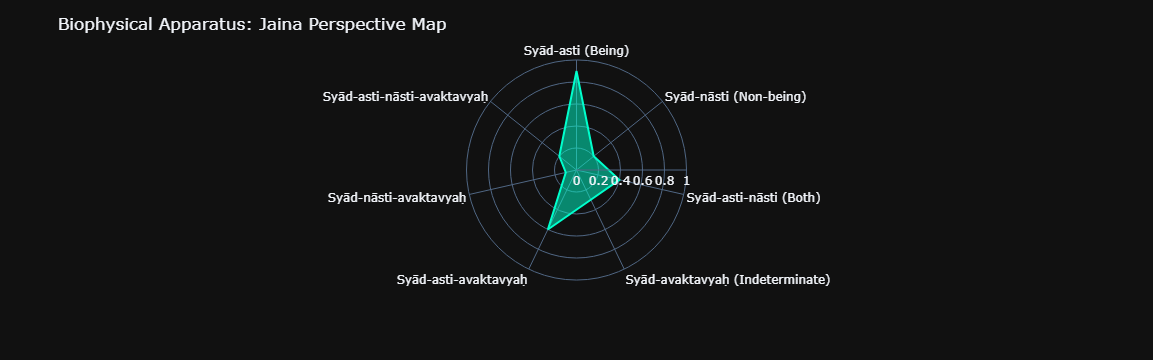

In [6]:
import plotly.express as px

# Define the 7 dimensions of Jaina logic for the HUD
categories = [
    'Syād-asti (Being)', 
    'Syād-nāsti (Non-being)', 
    'Syād-asti-nāsti (Both)', 
    'Syād-avaktavyaḥ (Indeterminate)',
    'Syād-asti-avaktavyaḥ', 
    'Syād-nāsti-avaktavyaḥ', 
    'Syād-asti-nāsti-avaktavyaḥ'
]

# Simulated intensity for each logic state (0.0 to 1.0)
# In a real setup, these would be fed by your FFT and sensor data
values = [0.9, 0.2, 0.4, 0.3, 0.6, 0.1, 0.2]

df_hud = pd.DataFrame(dict(r=values, theta=categories))

fig_hud = px.line_polar(df_hud, r='r', theta='theta', line_close=True,
                        template="plotly_dark", color_discrete_sequence=['#00FFCC'])
fig_hud.update_traces(fill='toself')
fig_hud.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=False,
    title="Biophysical Apparatus: Jaina Perspective Map"
)
fig_hud.show()

In [7]:
# Initialize the git repository
git init

# Add your notebook and any other files
git add Medical_Tricorder.ipynb

# Create your first commit
git commit -m "Initial commit: Medical Tricorder Engine with W-axis and Jaina logic"

SyntaxError: invalid syntax (2339040100.py, line 2)